# Calculate extremes
In this notebook, we visualize the extreme temperatures as sampled from the model. The objective is to determine the role that using the re-weighted loss has on model estimates.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import osmnx as ox

# Define your area of interest
place = "Durham, North Carolina, USA"  # or use a bounding box

west, south, east, north = -79.1, 35.8, -78.6, 36.3

G = ox.graph_from_bbox([west, south, east, north], network_type='drive', custom_filter='["highway"~"motorway|trunk"]')
edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

In [2]:
df = pd.read_csv('../experiments/extremes/extremes.csv')

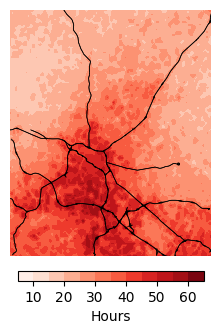

In [9]:
grid = df.pivot(index='lat', columns='lon', values='mean').sort_index(ascending=True)

lon_vals = grid.columns.values
lat_vals = grid.index.values

value_grid = grid.values

# plt.imshow(grid.values, cmap='terrain', origin='lower')#, vmin=0, vmax=4)
# plt.colorbar()

plt.figure(figsize=(3, 4))
cp = plt.contourf(lon_vals, lat_vals, value_grid, levels=np.arange(5, 66, 5), cmap='Reds')
# plt.colorbar(cp, label='Hours')

cbar = plt.colorbar(cp, label='Hours', orientation='horizontal', shrink=0.8, pad=0.05)
cbar.set_ticks(np.arange(10, 66, 10))
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')

edges.plot(ax=plt.gca(), color='black', linewidth=0.5, label='Major Roads')
plt.xlim(lon_vals.min(), lon_vals.max())
plt.ylim(lat_vals.min(), lat_vals.max())
plt.axis("off")
# plt.title("Mean # Hours > 95°F in Aug. 2024")'
plt.savefig(f'../figures/extremes_2024.pdf', dpi=300, bbox_inches='tight')

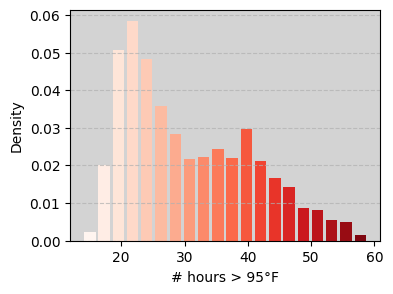

In [15]:


plt.figure(figsize=(4, 3))
b, n, patches = plt.hist(sorted(value_grid.flatten()), bins=20, rwidth=0.8, density=True)

colormap = plt.cm.Reds
normalized_counts = (n - n.min()) / (n.max() - n.min())

for count, patch in zip(normalized_counts, patches):
    plt.setp(patch, 'facecolor', colormap(count))

# Change background to grey
# plt.gcf().set_facecolor('grey')

# Change plot background to grey
plt.gca().set_facecolor('lightgrey')

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("# hours > 95°F")
plt.ylabel("Density")
# plt.show()
plt.savefig(f'../figures/extreme_histogram.pdf', dpi=1000, bbox_inches='tight')

In [18]:
count

np.float64(0.1569742020113686)

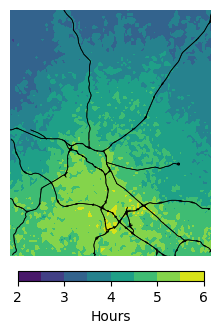

In [7]:
grid = df.pivot(index='lat', columns='lon', values='std').sort_index(ascending=True)

lon_vals = grid.columns.values
lat_vals = grid.index.values

value_grid = grid.values

# plt.imshow(grid.values, cmap='terrain', origin='lower')#, vmin=0, vmax=4)
# plt.colorbar()

plt.figure(figsize=(3, 4))
cp = plt.contourf(lon_vals, lat_vals, value_grid, levels=np.arange(2, 6.1, 0.5), cmap='viridis')
# plt.colorbar(cp, label='Hours')
# Increase colorbar font size to size 12, too
cbar = plt.colorbar(cp, label='Hours', orientation='horizontal', shrink=0.8, pad=0.05)
# colorbar font size to 12
# cbar.ax.tick_params(labelsize=12)
# change title font size too
# cbar.set_label('Hours', fontsize=14)
cbar.set_ticks(np.arange(2, 6.1, 1))
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# Increase font size to size 12
# plt.tick_params(labelsize=10)
edges.plot(ax=plt.gca(), color='black', linewidth=0.5, label='Major Roads')
plt.xlim(lon_vals.min(), lon_vals.max())
plt.ylim(lat_vals.min(), lat_vals.max())
plt.axis('off')
# plt.title("Mean # Hours > 95°F in Aug. 2024")
plt.savefig(f'../figures/extremes_var_2024.pdf', dpi=1000, bbox_inches='tight')